Features shape: (56640, 86)
Labels shape: (56640, 1)

Feature Statistics:
       %-rsi-period_10_ETH/USDTUSDT_1m  %-mfi-period_10_ETH/USDTUSDT_1m  \
count                     56640.000000                     56640.000000   
mean                          0.035896                        -0.009262   
std                           0.170775                         0.303760   
min                          -1.000000                        -1.000000   
25%                          -0.077357                        -0.227339   
50%                           0.036481                        -0.010718   
75%                           0.149837                         0.207697   
max                           1.000000                         1.000000   

       %-adx-period_10_ETH/USDTUSDT_1m  %-sma-period_10_ETH/USDTUSDT_1m  \
count                     56640.000000                     56640.000000   
mean                         -0.489718                        -0.021894   
std                      

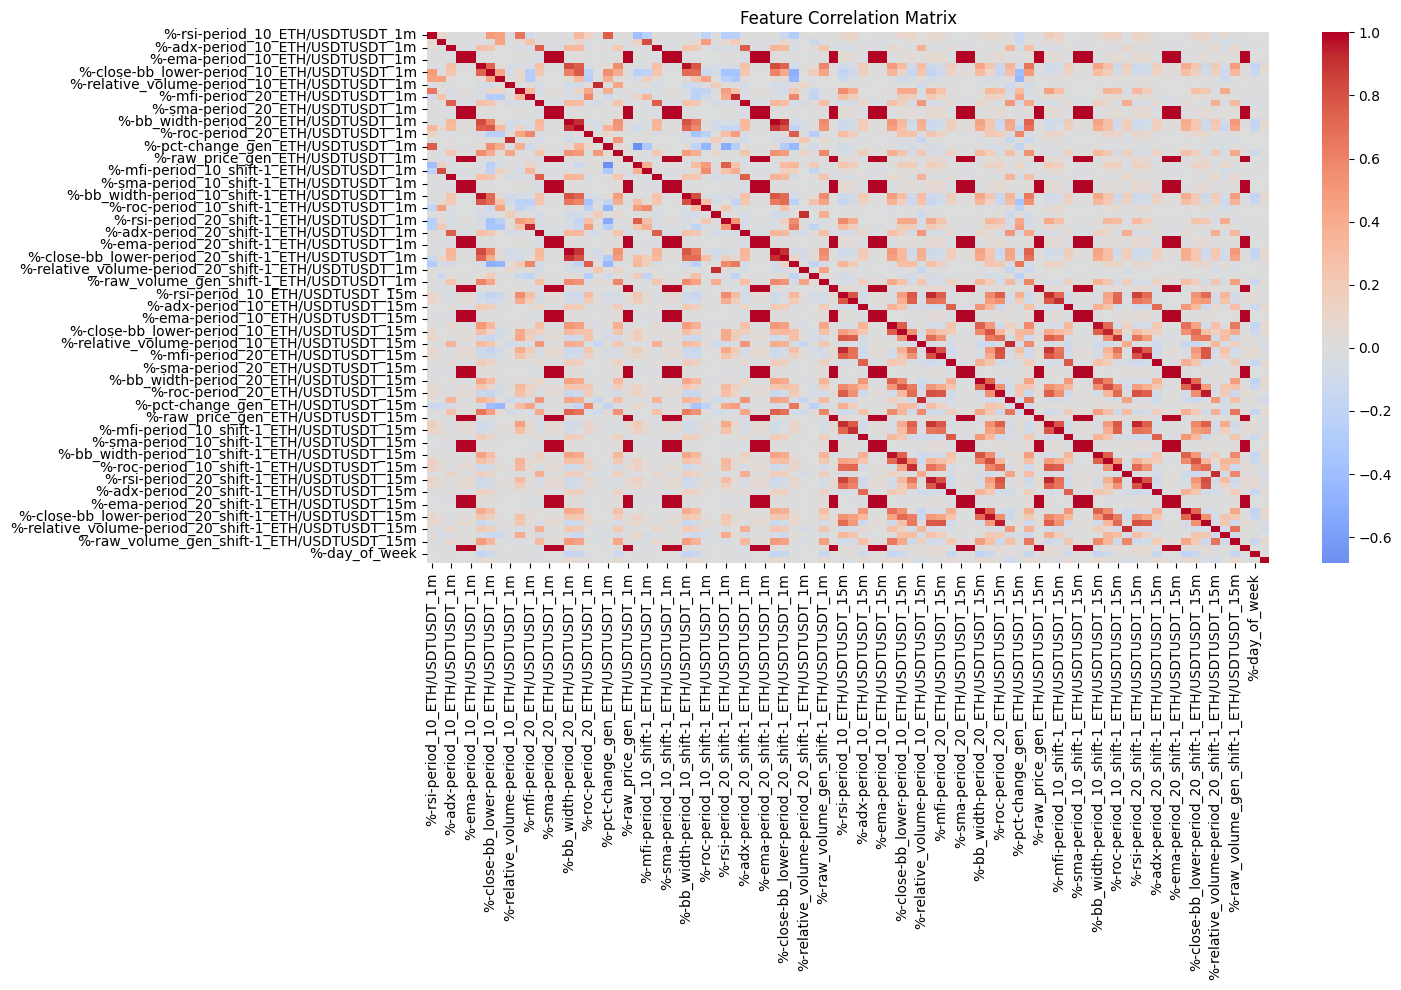

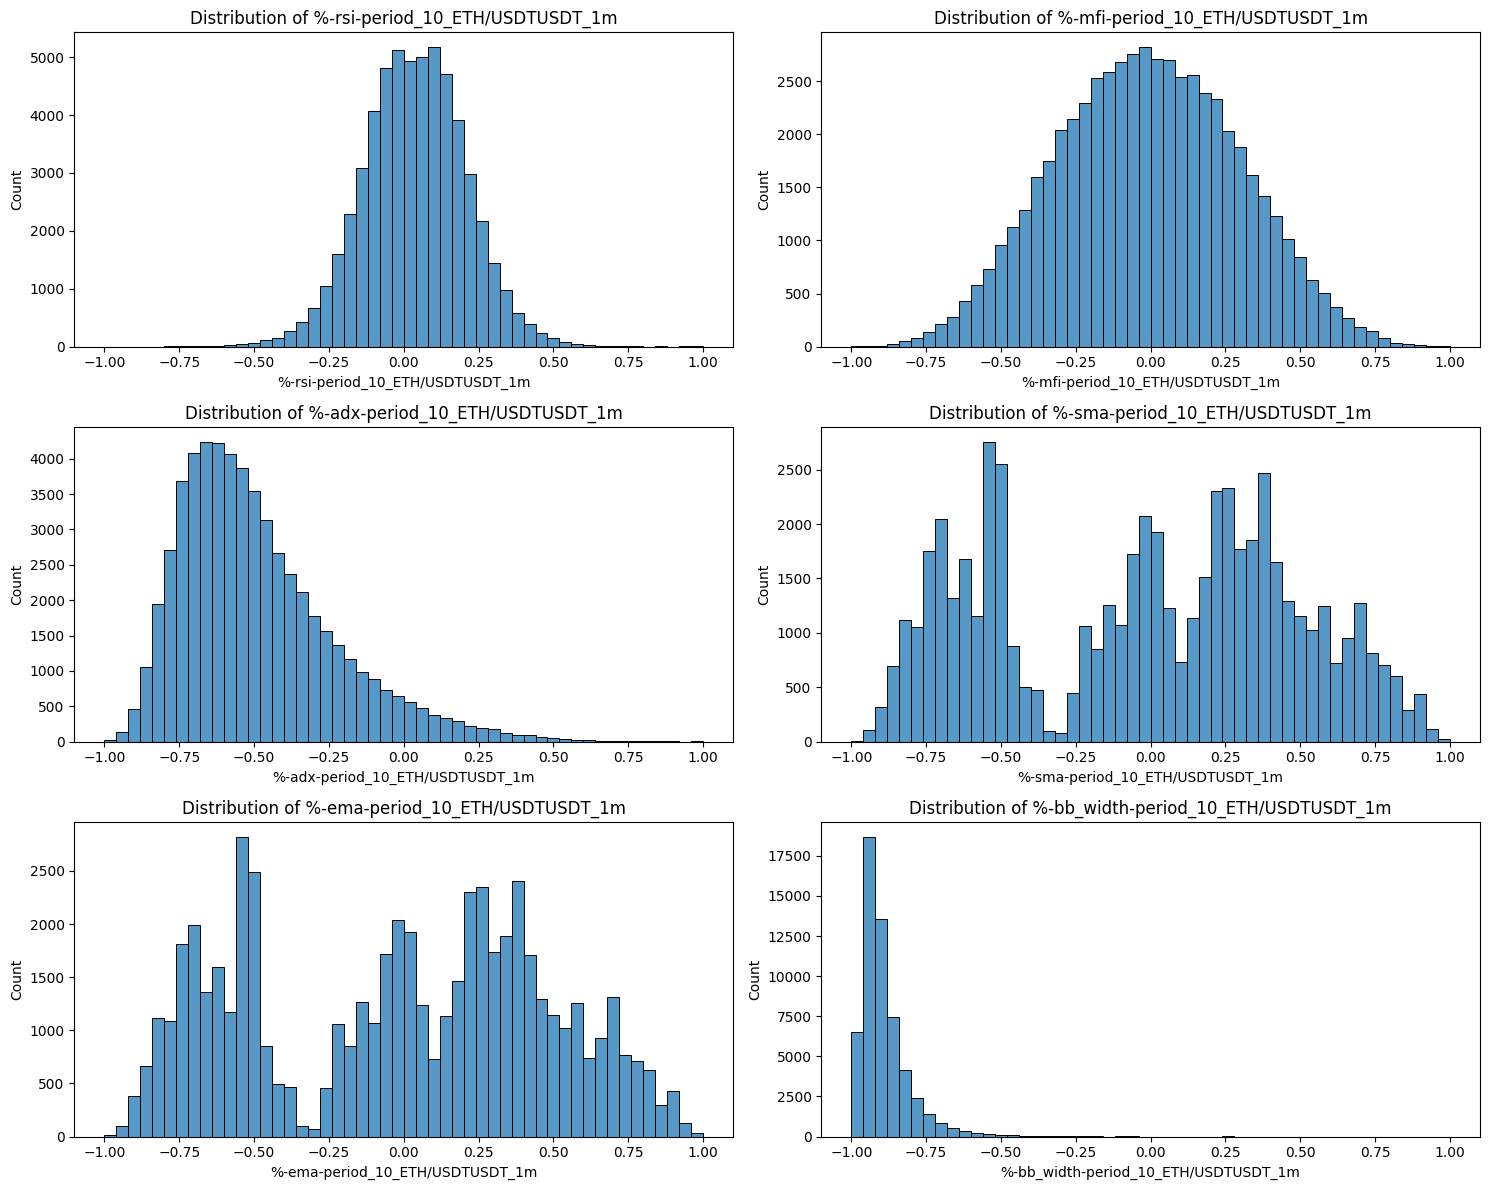

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Load feature and label files
features_df = pd.read_parquet('/allah/data/parquet/ETH/USDT:USDT_features_20250203_114859.parquet')
labels_df = pd.read_parquet('/allah/data/parquet/ETH/USDT:USDT_labels_20250203_114859.parquet')

# Basic analysis
print("Features shape:", features_df.shape)
print("Labels shape:", labels_df.shape)

# Analyze feature statistics
print("\nFeature Statistics:")
print(features_df.describe())

# Look at label distribution
print("\nLabel Distribution:")
print(labels_df['&-target'].value_counts(normalize=True))

# Plot correlation heatmap of features
plt.figure(figsize=(15,10))
feature_cols = [col for col in features_df.columns if '%' in col]
correlation_matrix = features_df[feature_cols].corr()
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Plot distributions of some key features
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.ravel()

for idx, col in enumerate(feature_cols[:6]):  # Plot first 6 features
    sns.histplot(data=features_df, x=col, bins=50, ax=axes[idx])
    axes[idx].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

# Check prediction confidence distribution if available
if 'do_predict' in features_df.columns:
    print("\nPrediction Confidence Distribution:")
    print(features_df['do_predict'].value_counts(normalize=True))


In [ ]:
features_df.head()

In [ ]:
# give the head of the features and labels
features_df.columns